# 4 · Participation, and how to silence a mode

**Math primer — notebook 4 of 7.**

This is the pivotal notebook. Everything so far has been standard vibration
theory; here is where the paper's idea appears, in a two-degree-of-freedom system
you can draw on a napkin.

**You should come out knowing:** what the modal participation factor is
geometrically, why a mode with zero participation is genuinely invisible, and —
the paper's actual problem — how to *move a mode shape* so that a **fixed**
excitation stops seeing it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import primer
from primer import SERIES, INK, INK2, GRID, tidy
primer.use_style()

## 4.1 · Forcing, in modal coordinates

From notebook 3, mode $r$ obeys $m_r\ddot\eta_r+k_r\eta_r=\{u^r\}^\mathsf{T}\{f\}$.
For harmonic forcing $\{f\}=\{F\}e^{i\omega t}$ the steady state is

$$\eta_r=\frac{\{u^r\}^\mathsf{T}\{F\}}{m_r\left(\omega_r^2-\omega^2\right)},
\qquad\text{so}\qquad
\{Q\}=\sum_r \frac{\{u^r\}\left(\{u^r\}^\mathsf{T}\{F\}\right)}{m_r\left(\omega_r^2-\omega^2\right)}$$

the paper's Eq. (6). The scalar

$$\Gamma_r=\{u^r\}^\mathsf{T}\{F\}$$

is the **modal participation factor**. Geometrically it is the projection of the
force vector onto the mode shape — how much of the push points along the way that
mode wants to move.

If $\Gamma_r=0$, mode $r$ receives no work from the force. Not "a little at
resonance". None, at any frequency.

## 4.2 · A system with both kinds of coupling

The two-mass chain from notebooks 1–3 is too simple for what comes next: it has
elastic coupling but no inertial coupling. So switch to a system that has both —
and which happens to be an exact structural analogue of the paper's problem.

**A rigid bar on two springs.** Mass $m$, moment of inertia $I_G$ about its own
centre of gravity, springs $k_f$ and $k_r$ at distances $a$ and $b$ either side of
the CG. Take as coordinates the vertical displacement $z$ of a **reference point
$P$** offset by $e$ from the CG, and the rotation $\theta$.

Because $P$ is not the CG, accelerating $P$ vertically also produces angular
acceleration — that is **inertial coupling**. Because the springs are not
symmetric about $P$, a vertical deflection also produces a moment — that is
**elastic coupling**. Both at once, exactly like $I_{zx}$ and $K_{\phi\psi}$ in
the paper.

In [2]:
def bar_system(m=12.0, I_G=0.55, k_f=9.0e3, k_r=6.0e3, a=0.32, b=0.28, e=0.0):
    """Rigid bar on two springs, coordinates (z at point P, theta).

    a, b are the spring positions measured from the CG (a forward, b rearward).
    e is the offset of the reference point P from the CG (positive forward).
    """
    # z_P = z_G + e*theta, so z_G = z_P - e*theta and the displacement at a
    # station x (measured from the CG) is  z_P + (x - e)*theta.
    # Kinetic energy (1/2) m (z_P - e th')^2 + (1/2) I_G th'^2 gives M12 = -m e.
    af, ar = a - e, -b - e            # spring stations relative to P
    M = np.array([[m,       -m * e],
                  [-m * e,   I_G + m * e**2]])
    K = np.array([[k_f + k_r,            k_f*af + k_r*ar],
                  [k_f*af + k_r*ar,      k_f*af**2 + k_r*ar**2]])
    return M, K

M, K = bar_system(e=0.10)
print("M =\n", M, "\n\nK =\n", K)
print("\ninertial coupling M12 =", M[0, 1], "   elastic coupling K12 =", K[0, 1])

M =
 [[12.   -1.2 ]
 [-1.2   0.67]] 

K =
 [[15000.  -300.]
 [ -300.  1302.]]

inertial coupling M12 = -1.2000000000000002    elastic coupling K12 = -300.0


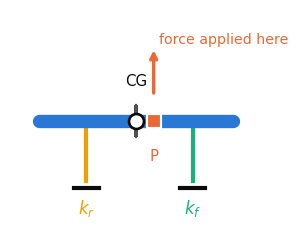

In [3]:
fig, ax = plt.subplots(figsize=(6.6, 2.1))
m, I_G, k_f, k_r, a, b, e = 12.0, 0.55, 9.0e3, 6.0e3, 0.32, 0.28, 0.10
ax.plot([-0.55, 0.55], [0, 0], color=SERIES[0], lw=8, solid_capstyle="round", zorder=3)
primer.spring(ax, 0, 0, y=0)   # noop keeps import used
for xs, kk, col in ((a, "$k_f$", SERIES[2]), (-b, "$k_r$", SERIES[3])):
    ax.plot([xs, xs], [-0.34, -0.05], color=col, lw=2.5, zorder=2)
    ax.plot([xs-0.07, xs+0.07], [-0.38, -0.38], color=INK, lw=2.5)
    ax.text(xs, -0.52, kk, ha="center", color=col, fontsize=10)
ax.plot([0], [0], "o", ms=9, color="white", markeredgecolor=INK, mew=1.6, zorder=4)
ax.text(0, 0.20, "CG", ha="center", color=INK, fontsize=9)
ax.plot([e], [0], "s", ms=8, color=SERIES[1], markeredgecolor="white", mew=1.3, zorder=4)
ax.text(e, -0.22, "P", ha="center", color=SERIES[1], fontsize=9)
ax.annotate("", xy=(e, 0.42), xytext=(e, 0.14),
            arrowprops=dict(arrowstyle="->", color=SERIES[1], lw=2))
ax.text(e + 0.03, 0.44, "force applied here", color=SERIES[1], fontsize=8.5)
ax.set_xlim(-0.7, 0.7); ax.set_ylim(-0.62, 0.62); ax.set_aspect("equal"); ax.axis("off")
plt.tight_layout(); plt.show()

## 4.3 · The excitation, and what it can and cannot see

Apply a pure vertical force at $P$: $\{F\}=[F_0,\ 0]^\mathsf{T}$ (a force at $P$
produces no moment *about $P$*). Then

$$\Gamma_r=\{u^r\}^\mathsf{T}\{F\}=u^r_z F_0$$

so mode $r$ is silent iff $u^r_z=0$ — iff that mode is a **pure rotation about
$P$**.

And that has a completely intuitive reading: if a mode's instantaneous centre of
rotation sits exactly at the point where you push, then your push does no work on
it. You are pushing at the pivot.

In [4]:
def analyse(e, F=np.array([1.0, 0.0]), **kw):
    """Frequencies [Hz], mode shapes (largest entry = 1), normalised participations."""
    M, K = bar_system(e=e, **kw)
    w2, V = eigh(K, M)
    V = V / V[np.argmax(np.abs(V), axis=0), np.arange(2)]
    gam = np.abs(V.T @ F) / (np.linalg.norm(V, axis=0) * np.linalg.norm(F))
    return np.sqrt(w2) / 2 / np.pi, V, gam

f_hz, V, gam = analyse(e=0.10)
for r in range(2):
    print(f"mode {r+1}: {f_hz[r]:6.2f} Hz   shape [z, theta] = {V[:, r]}   "
          f"participation = {gam[r]:.4f}")

mode 1:   5.27 Hz   shape [z, theta] = [-0.5569  1.    ]   participation = 0.4865
mode 2:   8.24 Hz   shape [z, theta] = [0.1698 1.    ]   participation = 0.1674


Both modes respond. Now sweep the reference-point offset $e$ — equivalently, move
where you push along the bar — and watch. `eigh` returns the modes in ascending
frequency, and (as the right-hand panel is about to show) the frequencies do not
move at all here, so "lower mode" and "upper mode" stay unambiguous labels
throughout the sweep.

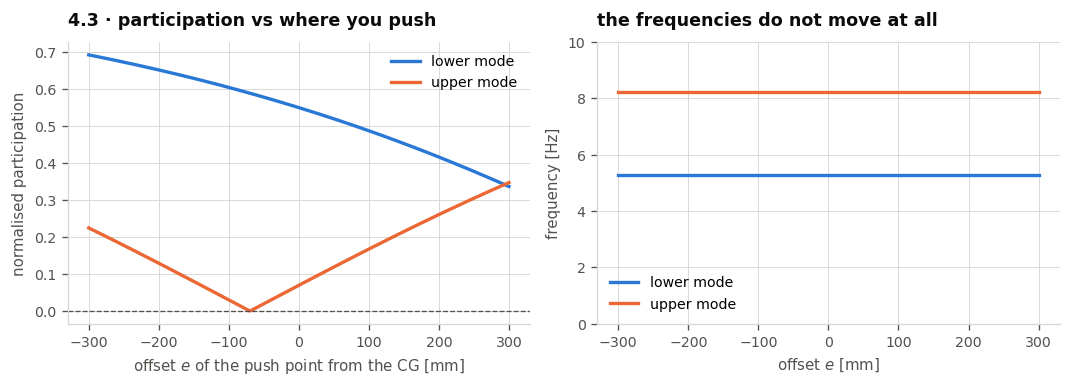

In [5]:
es = np.linspace(-0.30, 0.30, 500)
G = np.array([analyse(ei)[2] for ei in es])
FZ = np.array([analyse(ei)[0] for ei in es])

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.3))
axes[0].plot(es*1000, G[:, 0], color=SERIES[0], label="lower mode")
axes[0].plot(es*1000, G[:, 1], color=SERIES[1], label="upper mode")
axes[0].axhline(0, color=INK2, lw=0.8, ls="--")
tidy(axes[0], "4.3 · participation vs where you push",
     "offset $e$ of the push point from the CG [mm]", "normalised participation")
axes[0].legend()

axes[1].plot(es*1000, FZ[:, 0], color=SERIES[0], label="lower mode")
axes[1].plot(es*1000, FZ[:, 1], color=SERIES[1], label="upper mode")
axes[1].set_ylim(0, 10)
tidy(axes[1], "the frequencies do not move at all", "offset $e$ [mm]", "frequency [Hz]")
axes[1].legend()
plt.tight_layout(); plt.show()

Two things to notice.

1. The upper mode's participation touches **zero** at one offset in this range.
   That offset is the upper mode's centre of rotation — the classic "oscillation
   centre" of a bar on springs. (The lower mode has one too, but for these
   numbers it lies off the ends of the bar.)
2. **The natural frequencies do not change at all.** Of course they do not:
   moving the reference point is a change of coordinates, not a change of system
   — it is the congruence transform of notebook 1.5, which leaves the eigenvalues
   alone. Only the *shapes*, and hence the participations, are re-expressed.
   That flat line is also a good check that the mass matrix was written
   correctly: if it slopes, the inertia-coupling sign is wrong.

Rather than hunting for the dip numerically, use the condition that notebook 4.5
is about to derive: a mode is silent when $M_{12}/M_{22} = K_{12}/K_{22}$. As a
function of $e$ that is one scalar equation with one unknown.

In [6]:
from scipy.optimize import brentq

def mismatch(e, **kw):
    """M12/M22 - K12/K22.  Zero means one mode is invisible to a force at P."""
    M, K = bar_system(e=e, **kw)
    return M[0, 1]/M[1, 1] - K[0, 1]/K[1, 1]

def find_roots(fn, lo, hi, n=400):
    xs = np.linspace(lo, hi, n)
    vs = np.array([fn(x) for x in xs])
    out = []
    for i in range(n - 1):
        if np.isfinite(vs[i]) and np.isfinite(vs[i+1]) and vs[i]*vs[i+1] < 0:
            out.append(brentq(fn, xs[i], xs[i+1]))
    return out

roots_e = find_roots(mismatch, -0.29, 0.29)
print("silencing offsets [mm]:", np.round(np.array(roots_e)*1000, 3))
e_star = roots_e[0]
print(f"\nusing e = {e_star*1000:.3f} mm")

f_hz, V, gam = analyse(e_star)
print(f"\nfrequencies : {f_hz.round(2)} Hz")
print("mode shapes [z; theta]:\n", V)
print("participations:", gam)
quiet = int(np.argmin(gam))
print(f"\nmode {quiet+1} is a pure rotation: its z component is {V[0, quiet]:.2e}")

silencing offsets [mm]: [-69.776]

using e = -69.776 mm

frequencies : [5.27 8.24] Hz
mode shapes [z; theta]:
 [[-0.7266 -0.    ]
 [ 1.      1.    ]]
participations: [0.5878 0.    ]

mode 2 is a pure rotation: its z component is -5.46e-16


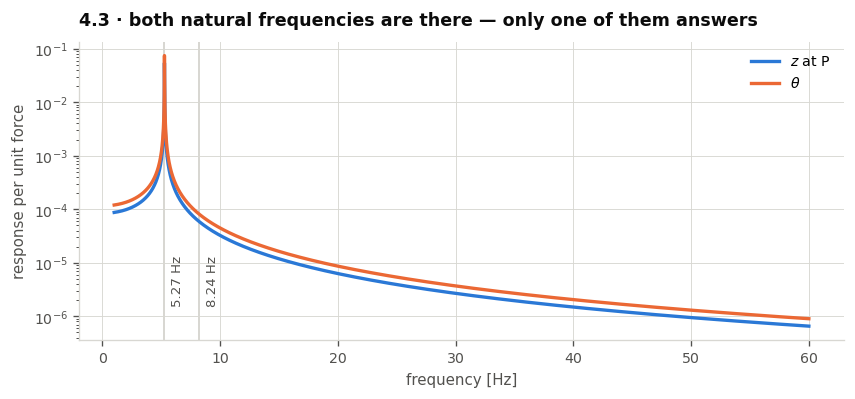

In [7]:
# ...and the response is a single-mode response at every frequency
Mx, Kx = bar_system(e=e_star)
w = 2*np.pi*np.linspace(1, 60, 3000)
F = np.array([1.0, 0.0])
Q = np.array([np.linalg.solve(-wi**2*Mx + Kx, F) for wi in w])

fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.semilogy(w/2/np.pi, np.abs(Q[:, 0]), color=SERIES[0], label="$z$ at P")
ax.semilogy(w/2/np.pi, np.abs(Q[:, 1]), color=SERIES[1], label=r"$\theta$")
for fr in f_hz:
    ax.axvline(fr, color=GRID, lw=1.2, zorder=0)
    ax.annotate(f"{fr:.2f} Hz", xy=(fr, 1e-6), xytext=(4, 6),
                textcoords="offset points", color=INK2, fontsize=8,
                rotation=90, va="bottom")
tidy(ax, "4.3 · both natural frequencies are there — only one of them answers",
     "frequency [Hz]", "response per unit force")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

Two grey lines, one peak. The second mode exists, sits right there in the
frequency range, and does nothing at all.

## 4.4 · The paper's version of the problem is the *inverse* one

In the sweep above we moved the excitation until it stopped seeing a mode. An
engine designer cannot do that: **the excitation is fixed by the engine.** The
crank produces a rocking couple about an axis set by the cylinder geometry, and
no amount of mount design changes it.

So the problem turns around:

> Given a fixed excitation direction $\{F\}$, choose the *system* so that one of
> its mode shapes becomes orthogonal to $\{F\}$.

In the bar: keep the push at $P$ where it is, and change the springs until a
mode's centre of rotation moves onto $P$.

stiffness ratio that silences a mode:  k_f/k_r = 1.2467

frequencies : [5.18 7.65] Hz
mode shapes :
 [[-0.9667  0.    ]
 [ 1.      1.    ]]
participations: [0.695 0.   ]


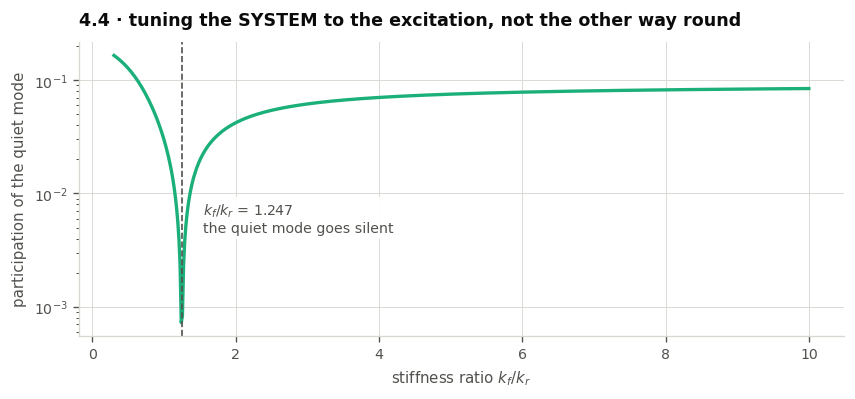

In [8]:
e_fixed = -0.05               # the push point is where the engine says it is
kr_base = 6.0e3

def mismatch_ratio(ratio):
    return mismatch(e_fixed, k_f=ratio*kr_base, k_r=kr_base)

r_star = find_roots(mismatch_ratio, 0.3, 10.0)[0]
print(f"stiffness ratio that silences a mode:  k_f/k_r = {r_star:.4f}")

f_hz, V, gam = analyse(e_fixed, k_f=r_star*kr_base, k_r=kr_base)
print(f"\nfrequencies : {f_hz.round(2)} Hz")
print("mode shapes :\n", V)
print("participations:", gam)

ratios = np.linspace(0.3, 10.0, 600)
lk = np.array([analyse(e_fixed, k_f=r*kr_base, k_r=kr_base)[2].min() for r in ratios])

fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.semilogy(ratios, lk, color=SERIES[2])
ax.axvline(r_star, color=INK2, ls="--", lw=1.0)
ax.text(r_star + 0.3, 0.006, f"$k_f/k_r$ = {r_star:.3f}\n"
        f"the quiet mode goes silent", color=INK2, fontsize=8.5, va="center",
        bbox=dict(fc="white", ec="none", alpha=0.9, pad=2))
tidy(ax, "4.4 · tuning the SYSTEM to the excitation, not the other way round",
     "stiffness ratio $k_f / k_r$", "participation of the quiet mode")
plt.tight_layout(); plt.show()

## 4.5 · The condition, in closed form

Do it algebraically rather than numerically, because the answer is literally the
paper's Eq. (16).

Require mode 2 to be pure rotation, $\{u^2\}=[0,\ 1]^\mathsf{T}$. Substitute into
$\left([K]-\omega_2^2[M]\right)\{u^2\}=0$ and read the two rows:

$$\text{row 1:}\quad K_{12}-\omega_2^2 M_{12}=0 \;\Rightarrow\; \omega_2^2=\frac{K_{12}}{M_{12}}$$
$$\text{row 2:}\quad K_{22}-\omega_2^2 M_{22}=0 \;\Rightarrow\; \omega_2^2=\frac{K_{22}}{M_{22}}$$

Both must hold, so

$$\boxed{\ \frac{M_{12}}{M_{22}}=\frac{K_{12}}{K_{22}}\ }$$

**The ratio of inertial coupling to inertia must equal the ratio of elastic
coupling to stiffness.** Put the paper's symbols in — $M_{12}=-I_{zx}$,
$M_{22}=I_z$, $K_{12}=K_{\phi\psi}$, $K_{22}=K_{\psi\psi}$ — and this is

$$-\frac{I_{zx}}{I_z}=\frac{K_{\phi\psi}}{K_{\psi\psi}}
\qquad\Longleftrightarrow\qquad
R=\frac{I_{zx}}{I_z}=-\frac{K_{\phi\psi}}{K_{\psi\psi}}$$

which is Eq. (16) exactly.

In [9]:
Mx, Kx = bar_system(e=e_fixed, k_f=r_star*kr_base, k_r=kr_base)
print(f"M12/M22 = {Mx[0,1]/Mx[1,1]:.8f}")
print(f"K12/K22 = {Kx[0,1]/Kx[1,1]:.8f}")
print("equal?", np.isclose(Mx[0,1]/Mx[1,1], Kx[0,1]/Kx[1,1]))
print(f"\nand w2^2 from both rows: {Kx[0,1]/Mx[0,1]:.4f}  vs  {Kx[1,1]/Mx[1,1]:.4f}")

M12/M22 = 1.03448276
K12/K22 = 1.03448276
equal? True

and w2^2 from both rows: 2312.8492  vs  2312.8492


### Why the same condition can also be read as orthogonality

The paper reaches it a different way — through the orthogonality conditions of
notebook 3 rather than through the eigenvector equation. Both routes give the
same determinant. Worth checking they agree:

$\{u^1\}^\mathsf{T}[M]\{u^2\}=0$ with $\{u^2\}=[0,1]^\mathsf{T}$ gives
$M_{12}u^1_1 + M_{22}u^1_2=0$; the $[K]$ version gives
$K_{12}u^1_1 + K_{22}u^1_2=0$. Two homogeneous equations in the same unknown
ratio — a non-trivial solution needs

$$\begin{vmatrix}M_{12}&M_{22}\\K_{12}&K_{22}\end{vmatrix}=0$$

the same condition. (In the paper this is Eqs. (13)–(15).)

In [10]:
det = Mx[0,1]*Kx[1,1] - Mx[1,1]*Kx[0,1]
print(f"determinant of the orthogonality pair: {det:.3e}  (should be ~0)")

# the surviving mode's shape ratio, from either row
print(f"u1_theta / u1_z  from M:  {-Mx[0,1]/Mx[1,1]:.6f}")
print(f"                 from K:  {-Kx[0,1]/Kx[1,1]:.6f}")
w2v, Vv = eigh(Kx, Mx)
Vv = Vv / Vv[np.argmax(np.abs(Vv), axis=0), np.arange(2)]
live = int(np.argmax(np.abs(Vv.T @ np.array([1.0, 0.0]))))
print(f"                 actual:  {Vv[1, live]/Vv[0, live]:.6f}")

determinant of the orthogonality pair: -2.501e-12  (should be ~0)
u1_theta / u1_z  from M:  -1.034483
                 from K:  -1.034483
                 actual:  -1.034483


## 4.6 · What this bought, and what it did not

The bar now has two resonances but only one of them can be excited. So the
designer is free to place the *other* one anywhere at all — high, for stiffness —
without paying for it in vibration.

What it did **not** buy: the live mode is still live. You still have to put it
somewhere sensible, and you still have to drive through it. That is the honest
limit of the method, and it is why the paper's own Fig. 14 shows the machine
being *worse* right at the resonance crossing.

---

**Next:** [5 · From point masses to a rigid body](05_rigid_body_and_inertia.ipynb)